Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DAY 3: SENTIMENT ANALYSIS
Loaded from Google Drive: 14640 tweets
Dataset saved to Google Drive: 14640 tweets
Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Sentiment distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


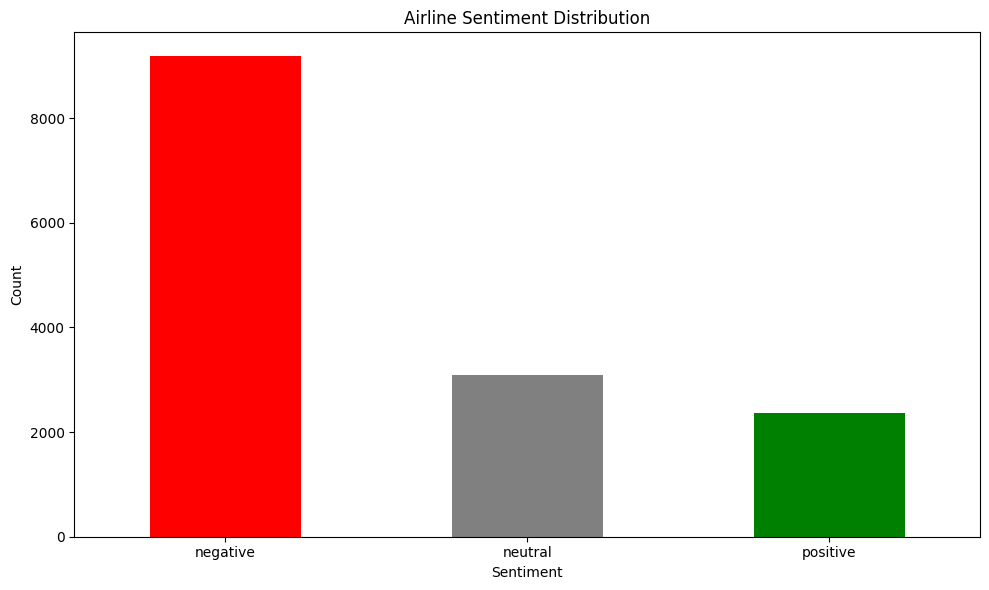


Preprocessing tweets...
Classes: ['negative' 'neutral' 'positive']


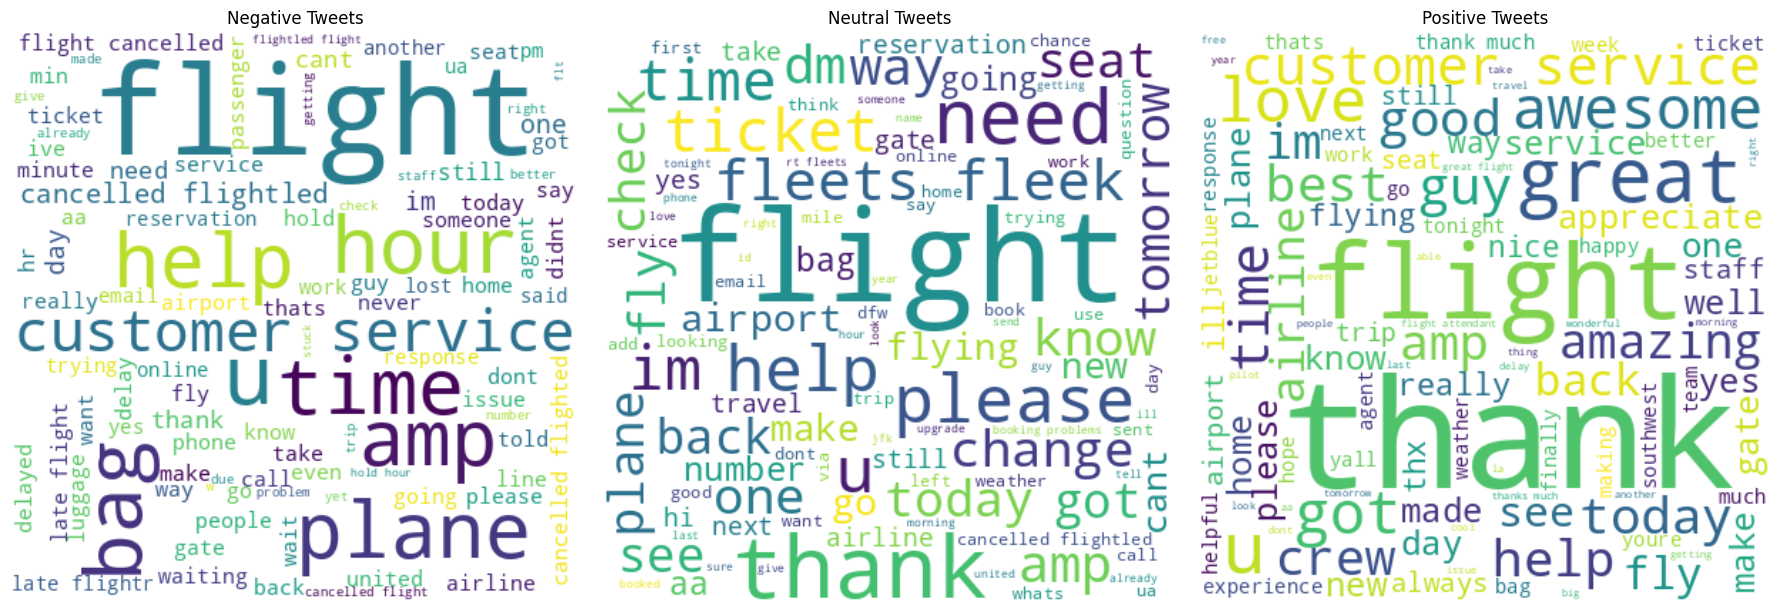


Creating features...
TF-IDF shape: (11712, 5000)
BoW shape: (11712, 5000)

Training models...
1/4: Logistic Regression
   Accuracy: 0.7797
2/4: Naive Bayes
   Accuracy: 0.7596
3/4: SVM
   Accuracy: 0.7763
4/4: Random Forest
   Accuracy: 0.6407

All models trained!

RESULTS
              Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Logistic Regression  0.779713           0.756575        0.658676          0.693328
                SVM  0.776298           0.765020        0.640796          0.678575
        Naive Bayes  0.759563           0.704276        0.668692          0.683186
      Random Forest  0.640710           0.784249        0.359074          0.308955

Best Model: Logistic Regression
Accuracy: 0.7797
F1-Score: 0.6933

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.94      0.86      1835
     neutral       0.65      0.47      0.55       620
    positive       0.82      0.56      0.67       473

 

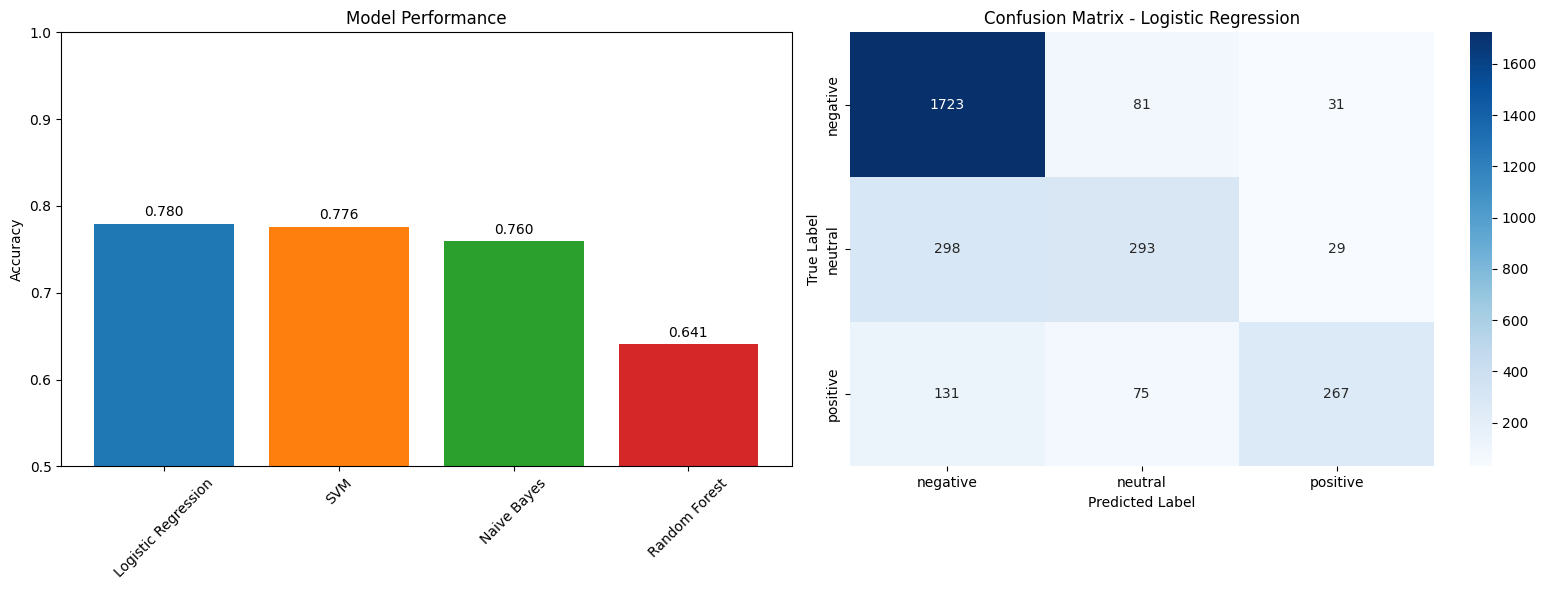


Top words for each sentiment:

Negative:
  Positive: ['call', 'cancelled', 'nothing', 'luggage', 'hrs', 'hour', 'hold', 'worst', 'delayed', 'hours']
  Negative: ['thank', 'thanks', 'love', 'great', 'awesome', 'amazing', 'best', 'hi', 'cant wait', 'worries']

Neutral:
  Positive: ['ceo', 'tomorrow', 'possible', 'need', 'march', 'atlanta', 'winners', 'dm', 'chance', 'hi']
  Negative: ['great', 'airline', 'helpful', 'customers', 'customer', 'made', 'lost', 'delayed', 'hours', 'awesome']

Positive:
  Positive: ['wonderful', 'appreciate', 'thx', 'amazing', 'best', 'love', 'awesome', 'thank', 'great', 'thanks']
  Negative: ['hours', 'need', 'worst', 'hold', 'delayed', 'call', 'hour', 'website', 'passengers', 'feedback']

Saving results to Google Drive...
Files saved:
  - day3_results.csv
  - day3_predictions.csv

DAY 3 COMPLETE!

Best Model: Logistic Regression
Best Accuracy: 0.7797


In [2]:

# DAY 3: SENTIMENT ANALYSIS - TWITTER AIRLINE SENTIMENT
# Models: Logistic Regression, Naive Bayes, SVM, Random Forest


!pip install scikit-learn pandas matplotlib seaborn nltk wordcloud -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from wordcloud import WordCloud

from google.colab import drive
drive.mount('/content/drive')

print("="*70)
print("DAY 3: SENTIMENT ANALYSIS")
print("="*70)


# 1. LOAD DATASET
df = pd.read_csv('/content/Tweets.csv')
print(f"Loaded from Google Drive: {df.shape[0]} tweets")


# Save to Drive for future use
df.to_csv('/content/drive/MyDrive/Twitter_airline_sentiment.csv', index=False)
print(f"Dataset saved to Google Drive: {df.shape[0]} tweets")

print(f"Columns: {df.columns.tolist()}")


# 2. EXPLORE DATA


print("\nSentiment distribution:")
print(df['airline_sentiment'].value_counts())

plt.figure(figsize=(10, 6))
df['airline_sentiment'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Airline Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. PREPROCESSING


print("\nPreprocessing tweets...")
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_text'] = df['text'].apply(clean_tweet)

# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])

print(f"Classes: {label_encoder.classes_}")


# 4. WORD CLOUDS


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(label_encoder.classes_):
    sentiment_text = ' '.join(df[df['label'] == idx]['cleaned_text'])
    wordcloud = WordCloud(width=400, height=400, background_color='white', max_words=100).generate(sentiment_text)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{sentiment.capitalize()} Tweets')

plt.tight_layout()
plt.show()


# 5. FEATURE ENGINEERING


print("\nCreating features...")

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# TF-IDF for LR, SVM, RF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# BoW for Naive Bayes
bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"BoW shape: {X_train_bow.shape}")


# 6. TRAIN MODELS


print("\nTraining models...")
print("="*70)

models = {}
predictions = {}
metrics = {}

# Logistic Regression
print("1/4: Logistic Regression")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
models['Logistic Regression'] = lr
predictions['Logistic Regression'] = y_pred_lr
metrics['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1-Macro': f1_score(y_test, y_pred_lr, average='macro')
}
print(f"   Accuracy: {metrics['Logistic Regression']['Accuracy']:.4f}")

# Naive Bayes
print("2/4: Naive Bayes")
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)
models['Naive Bayes'] = nb
predictions['Naive Bayes'] = y_pred_nb
metrics['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'F1-Macro': f1_score(y_test, y_pred_nb, average='macro')
}
print(f"   Accuracy: {metrics['Naive Bayes']['Accuracy']:.4f}")

# SVM
print("3/4: SVM")
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
models['SVM'] = svm
predictions['SVM'] = y_pred_svm
metrics['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'F1-Macro': f1_score(y_test, y_pred_svm, average='macro')
}
print(f"   Accuracy: {metrics['SVM']['Accuracy']:.4f}")

# Random Forest
print("4/4: Random Forest")
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
models['Random Forest'] = rf
predictions['Random Forest'] = y_pred_rf
metrics['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1-Macro': f1_score(y_test, y_pred_rf, average='macro')
}
print(f"   Accuracy: {metrics['Random Forest']['Accuracy']:.4f}")

print("\nAll models trained!")
print("="*70)


# 7. RESULTS


print("\n" + "="*70)
print("RESULTS")
print("="*70)

results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': m['Accuracy'],
        'Precision (macro)': precision_score(y_test, predictions[name], average='macro'),
        'Recall (macro)': recall_score(y_test, predictions[name], average='macro'),
        'F1-Score (macro)': m['F1-Macro']
    }
    for name, m in metrics.items()
])

results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))


# 8. BEST MODEL


best_model = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score (macro)']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, predictions[best_model], target_names=label_encoder.classes_))


# 9. VISUALIZATIONS


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
ax1 = axes[0]
bars = ax1.bar(results_df['Model'], results_df['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Performance')
ax1.set_ylim(0.5, 1.0)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom')

# Confusion matrix
ax2 = axes[1]
cm = confusion_matrix(y_test, predictions[best_model])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax2)
ax2.set_title(f'Confusion Matrix - {best_model}')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 10. TOP WORDS PER SENTIMENT


print("\nTop words for each sentiment:")

for idx, sentiment in enumerate(label_encoder.classes_):
    coefs = lr.coef_[idx]
    top_indices = np.argsort(coefs)[-10:]
    bottom_indices = np.argsort(coefs)[:10]

    print(f"\n{sentiment.capitalize()}:")
    print(f"  Positive: {[tfidf.get_feature_names_out()[i] for i in top_indices]}")
    print(f"  Negative: {[tfidf.get_feature_names_out()[i] for i in bottom_indices]}")


# 11. SAVE RESULTS


print("\nSaving results to Google Drive...")

results_df.to_csv('/content/drive/MyDrive/day3_results.csv', index=False)

predictions_df = pd.DataFrame({
    'tweet': X_test,
    'true_sentiment': label_encoder.inverse_transform(y_test),
    'lr_pred': label_encoder.inverse_transform(y_pred_lr),
    'nb_pred': label_encoder.inverse_transform(y_pred_nb),
    'svm_pred': label_encoder.inverse_transform(y_pred_svm),
    'rf_pred': label_encoder.inverse_transform(y_pred_rf)
})
predictions_df.to_csv('/content/drive/MyDrive/day3_predictions.csv', index=False)

print("Files saved:")
print("  - day3_results.csv")
print("  - day3_predictions.csv")

print("\n" + "="*70)
print("DAY 3 COMPLETE!")
print("="*70)
print(f"\nBest Model: {best_model}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")